# CASMI26 ICEBERG — Complete Dataset Analysis

**Dataset:** `casmi26-iceberg`  
**Author:** Mobeen Fatima

This notebook is designed for the Kaggle `casmi26-iceberg` dataset. Public CASMI26 resources describe this dataset as the **MIT ms-pred ICEBERG forward-cleavage runner and wheels**, used in the Enveda CASMI 2026 molecule-identification ecosystem.

Because this is a software/artifact dataset rather than a conventional CSV dataset, the notebook focuses on file inventory, package metadata, wheel structure, Python/platform compatibility, ICEBERG modules, dependencies, checksums, reproducibility, and an exportable artifact report.

In [1]:
import os, re, json, glob, hashlib, platform, zipfile, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 150)
print("Python:", platform.python_version())
print("Platform:", platform.platform())

Python: 3.13.15
Platform: Linux-6.18.48+-x86_64-with-glibc2.39


## 1.Locate Kaggle input files

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [2]:
INPUT_ROOT=Path("/kaggle/input")
all_files=[Path(p) for p in glob.glob("/kaggle/input/**/*",recursive=True) if Path(p).is_file()]
print("Mounted files:",len(all_files))
for p in all_files: print(p)

Mounted files: 40
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/MANIFEST.json
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/ice_runner.py
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/README.md
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/LICENSE-NOTICE.txt
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/fuse.py
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/ckpt/gen.pt
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/ckpt/inten.pt
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/wheels/einops-0.8.2-py3-none-any.whl.ice
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/wheels/torchmetrics-1.9.0-py3-none-any.whl.ice
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/wheels/lightning_utilities-0.15.3-py3-none-any.whl.ice
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/wheels/rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice
/kaggle/input/datasets/ahmedberatozer/casmi26-iceberg/wheels/pytorch_lightning-2.6.6-py3-n

## 2.Identify dataset directory

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [3]:
slug="casmi26-iceberg"
dirs=[p for p in INPUT_ROOT.rglob("*") if p.is_dir() and slug in p.name.lower()]
if dirs: DATA_DIR=dirs[0]
else:
    scores={p.parent:sum(x in str(p.parent).lower() for x in ["casmi","iceberg","mspred"]) for p in all_files}
    if not scores or max(scores.values())==0: raise FileNotFoundError("Attach casmi26-iceberg to the notebook.")
    DATA_DIR=max(scores,key=scores.get)
print("Dataset directory:",DATA_DIR)

Dataset directory: /kaggle/input/datasets/ahmedberatozer/casmi26-iceberg


## 3.Create complete file inventory

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [4]:
dataset_files=[p for p in DATA_DIR.rglob("*") if p.is_file()]
inventory=pd.DataFrame([{"file_name":p.name,"relative_path":str(p.relative_to(DATA_DIR)),"extension":p.suffix.lower() or "[none]","size_bytes":p.stat().st_size,"size_mb":p.stat().st_size/1024**2} for p in dataset_files]).sort_values("size_bytes",ascending=False).reset_index(drop=True)
display(inventory)

,file_name,relative_path,extension,size_bytes,size_mb
0,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,wheels/rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.ice,36119142,34.445898
1,gen.pt,ckpt/gen.pt,.pt,14561244,13.886684
2,inten.pt,ckpt/inten.pt,.pt,13793037,13.154065
3,torchmetrics-1.9.0-py3-none-any.whl.ice,wheels/torchmetrics-1.9.0-py3-none-any.whl.ice,.ice,983384,0.937828
4,pytorch_lightning-2.6.6-py3-none-any.whl.ice,wheels/pytorch_lightning-2.6.6-py3-none-any.whl.ice,.ice,853045,0.813527
5,misc_utils.py,src/ms_pred/common/misc_utils.py,.py,96988,0.092495
6,einops-0.8.2-py3-none-any.whl.ice,wheels/einops-0.8.2-py3-none-any.whl.ice,.ice,65638,0.062597
7,nn_utils.py,src/ms_pred/nn_utils/nn_utils.py,.py,41337,0.039422
8,dag_data.py,src/ms_pred/iceberg/dag_data.py,.py,36155,0.034480
9,gen_model.py,src/ms_pred/iceberg/gen_model.py,.py,34864,0.033249


## 4.Calculate storage footprint

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [5]:
total_bytes=inventory.size_bytes.sum()
print(f"Files: {len(inventory)}")
print(f"Total storage: {total_bytes/1024**2:.2f} MB")
print(f"Largest file: {inventory.iloc[0].file_name if len(inventory) else 'None'}")

Files: 40
Total storage: 63.82 MB
Largest file: rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice


## 5.Analyze file extensions

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

,file_count
extension,
.py,29
.ice,5
.pt,2
.json,1
.md,1
[none],1
.txt,1


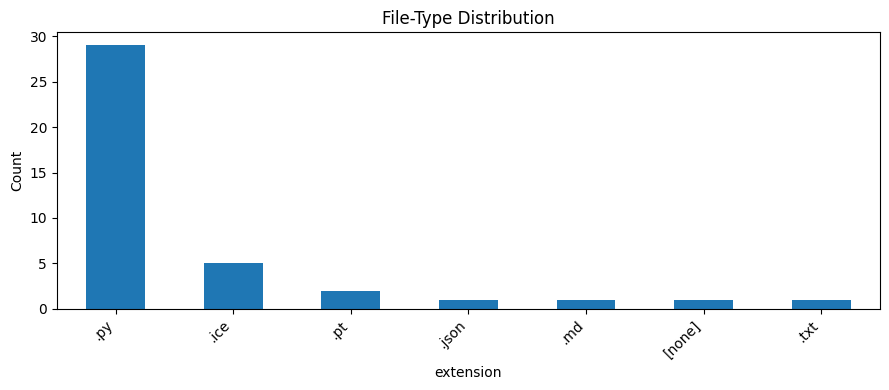

In [6]:
ext_counts=inventory.extension.value_counts()
display(ext_counts.to_frame("file_count"))
plt.figure(figsize=(9,4)); ext_counts.plot(kind="bar"); plt.title("File-Type Distribution"); plt.ylabel("Count"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.show()

## 6.Visualize artifact sizes

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

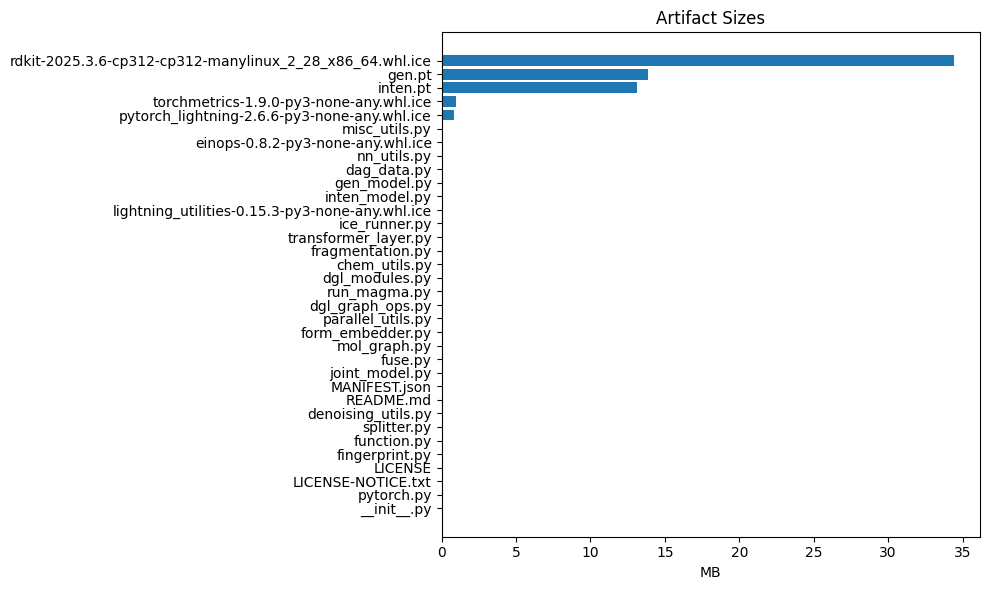

In [7]:
x=inventory.sort_values("size_mb")
plt.figure(figsize=(10,6)); plt.barh(x.file_name,x.size_mb); plt.xlabel("MB"); plt.title("Artifact Sizes"); plt.tight_layout(); plt.show()

## 7.Identify wheels and archives

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [8]:
wheel_files=[p for p in dataset_files if p.suffix.lower()==".whl"]
zip_files=[p for p in dataset_files if zipfile.is_zipfile(p)]
print("Wheels:",len(wheel_files))
print("ZIP-compatible:",len(zip_files))
for p in wheel_files: print("WHEEL:",p.name)

Wheels: 0
ZIP-compatible: 7


## 8.Inspect artifact filenames

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [9]:
for p in dataset_files: print(p.name)

MANIFEST.json
ice_runner.py
README.md
LICENSE-NOTICE.txt
fuse.py
gen.pt
inten.pt
einops-0.8.2-py3-none-any.whl.ice
torchmetrics-1.9.0-py3-none-any.whl.ice
lightning_utilities-0.15.3-py3-none-any.whl.ice
rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice
pytorch_lightning-2.6.6-py3-none-any.whl.ice
function.py
__init__.py
__init__.py
__init__.py
pytorch.py
__init__.py
LICENSE
__init__.py
fragmentation.py
run_magma.py
dag_data.py
gen_model.py
joint_model.py
inten_model.py
mol_graph.py
nn_utils.py
form_embedder.py
dgl_graph_ops.py
transformer_layer.py
dgl_modules.py
__init__.py
parallel_utils.py
splitter.py
chem_utils.py
fingerprint.py
__init__.py
denoising_utils.py
misc_utils.py


## 9.Extract software versions

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [10]:
pat=re.compile(r"(?<!\d)v?(\d+\.\d+(?:\.\d+)?(?:[-+][A-Za-z0-9._-]+)?)")
display(pd.DataFrame([{"file":p.name,"versions":", ".join(pat.findall(p.name))} for p in dataset_files]))

,file,versions
0,MANIFEST.json,
1,ice_runner.py,
2,README.md,
3,LICENSE-NOTICE.txt,
4,fuse.py,
5,gen.pt,
6,inten.pt,
7,einops-0.8.2-py3-none-any.whl.ice,0.8.2-py3-none-any.whl.ice
8,torchmetrics-1.9.0-py3-none-any.whl.ice,1.9.0-py3-none-any.whl.ice
9,lightning_utilities-0.15.3-py3-none-any.whl.ice,0.15.3-py3-none-any.whl.ice


## 10.Extract Python compatibility

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [11]:
pat=re.compile(r"(cp3\d{1,2}|pp3\d{1,2}|py3(?:\.\d+)?)",re.I)
display(pd.DataFrame([{"file":p.name,"python_abi":", ".join(sorted(set(pat.findall(p.name))))} for p in dataset_files]))

,file,python_abi
0,MANIFEST.json,
1,ice_runner.py,
2,README.md,
3,LICENSE-NOTICE.txt,
4,fuse.py,
5,gen.pt,
6,inten.pt,
7,einops-0.8.2-py3-none-any.whl.ice,py3
8,torchmetrics-1.9.0-py3-none-any.whl.ice,py3
9,lightning_utilities-0.15.3-py3-none-any.whl.ice,py3


## 11.Extract platform and architecture indicators

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [12]:
terms=["manylinux","linux","win","windows","x86_64","amd64","aarch64","arm64","cuda","cu11","cu12"]
display(pd.DataFrame([{"file":p.name,"indicators":", ".join(t for t in terms if t in p.name.lower())} for p in dataset_files]))

,file,indicators
0,MANIFEST.json,
1,ice_runner.py,
2,README.md,
3,LICENSE-NOTICE.txt,
4,fuse.py,
5,gen.pt,
6,inten.pt,
7,einops-0.8.2-py3-none-any.whl.ice,
8,torchmetrics-1.9.0-py3-none-any.whl.ice,
9,lightning_utilities-0.15.3-py3-none-any.whl.ice,


## 12.Detect ICEBERG-related artifacts

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [13]:
terms=["iceberg","ms_pred","mspred","fragment","cleavage","spectrum"]
rows=[]
for p in dataset_files:
    s=str(p.relative_to(DATA_DIR)).lower()
    rows.append({"file":str(p.relative_to(DATA_DIR)),"matched_terms":", ".join(t for t in terms if t in s)})
display(pd.DataFrame(rows))

,file,matched_terms
0,MANIFEST.json,
1,ice_runner.py,
2,README.md,
3,LICENSE-NOTICE.txt,
4,fuse.py,
5,ckpt/gen.pt,
6,ckpt/inten.pt,
7,wheels/einops-0.8.2-py3-none-any.whl.ice,
8,wheels/torchmetrics-1.9.0-py3-none-any.whl.ice,
9,wheels/lightning_utilities-0.15.3-py3-none-any.whl.ice,


## 13.Generate SHA-256 checksums

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [14]:
def sha256(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1024*1024),b""): h.update(chunk)
    return h.hexdigest()
checksums=pd.DataFrame([{"file":p.name,"size_bytes":p.stat().st_size,"sha256":sha256(p)} for p in dataset_files])
display(checksums)

,file,size_bytes,sha256
0,MANIFEST.json,6163,78ab2dff112b1e9a043a8025bf8b57839be3f4b94f2e87fc61becbef4c804f8b
1,ice_runner.py,31551,dc0d5d1e14053e2e7d9088817c620d6615372abc3afdd02be2fc7ff9ee0b2802
2,README.md,3879,1a36864cb19161b84742f9cb8f323f795b5b3e8e1d739474b7b205acd2d8601f
3,LICENSE-NOTICE.txt,1003,2bdc24cdcfda1c536a17d8af6a85b6028b19369527d84db8cc81800228897bce
4,fuse.py,8349,6d1bdf0c63ff8844d6994bb83cdadf07951ee40ed87ea5a2d870577c6fc76bb1
5,gen.pt,14561244,deef0451c1870d2125653bb212c9d95c5b5d9bf80156dfa9b22fedda7db49bea
6,inten.pt,13793037,c49e330e049d3a8b0095026ed694fcf70045c24305354853732aaa5f89d55068
7,einops-0.8.2-py3-none-any.whl.ice,65638,54058201ac7087911181bfec4af6091bb59380360f069276601256a76af08193
8,torchmetrics-1.9.0-py3-none-any.whl.ice,983384,bfdcbff3dd1d96b3374bb2496eb39f23c4b28b8a845b6a18c313688e0d2d9ca1
9,lightning_utilities-0.15.3-py3-none-any.whl.ice,31906,6c55f1bee70084a1cbeaa41ada96e4b3a0fea5909e844dd335bd80f5a73c5f91


## 14.Inspect binary signatures

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [15]:
rows=[]
for p in dataset_files:
    with open(p,"rb") as f: header=f.read(16)
    rows.append({"file":p.name,"extension":p.suffix.lower(),"header_hex":header.hex(" ")})
display(pd.DataFrame(rows))

,file,extension,header_hex
0,MANIFEST.json,.json,7b 0d 0a 20 22 6e 61 6d 65 22 3a 20 22 63 61 73
1,ice_runner.py,.py,23 21 2f 75 73 72 2f 62 69 6e 2f 65 6e 76 20 70
2,README.md,.md,23 20 63 61 73 6d 69 32 36 2d 69 63 65 62 65 72
3,LICENSE-NOTICE.txt,.txt,54 68 69 72 64 2d 70 61 72 74 79 20 63 6f 6d 70
4,fuse.py,.py,22 22 22 4e 6f 74 65 62 6f 6f 6b 2d 73 69 64 65
5,gen.pt,.pt,50 4b 03 04 00 00 08 08 00 00 00 00 00 00 00 00
6,inten.pt,.pt,50 4b 03 04 00 00 08 08 00 00 00 00 00 00 00 00
7,einops-0.8.2-py3-none-any.whl.ice,.ice,50 4b 03 04 14 00 00 00 08 00 00 00 42 50 b4 56
8,torchmetrics-1.9.0-py3-none-any.whl.ice,.ice,50 4b 03 04 14 00 00 00 08 00 18 8d 69 5c fa 17
9,lightning_utilities-0.15.3-py3-none-any.whl.ice,.ice,50 4b 03 04 14 00 00 00 08 00 e3 44 4b 5c 4e 70


## 15.Inspect wheel/archive contents

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [16]:
for p in zip_files:
    print("\n===",p.name,"===")
    try:
        with zipfile.ZipFile(p) as z:
            print("Members:",len(z.namelist()))
            for n in z.namelist()[:60]: print(n)
    except Exception as e: print("Error:",e)


=== gen.pt ===
Members: 31
gen/data.pkl
gen/.format_version
gen/.storage_alignment
gen/byteorder
gen/data/0
gen/data/1
gen/data/2
gen/data/3
gen/data/4
gen/data/5
gen/data/6
gen/data/7
gen/data/8
gen/data/9
gen/data/10
gen/data/11
gen/data/12
gen/data/13
gen/data/14
gen/data/15
gen/data/16
gen/data/17
gen/data/18
gen/data/19
gen/data/20
gen/data/21
gen/data/22
gen/data/23
gen/data/24
gen/version
gen/.data/serialization_id

=== inten.pt ===
Members: 72
inten/data.pkl
inten/.format_version
inten/.storage_alignment
inten/byteorder
inten/data/0
inten/data/1
inten/data/2
inten/data/3
inten/data/4
inten/data/5
inten/data/6
inten/data/7
inten/data/8
inten/data/9
inten/data/10
inten/data/11
inten/data/12
inten/data/13
inten/data/14
inten/data/15
inten/data/16
inten/data/17
inten/data/18
inten/data/19
inten/data/20
inten/data/21
inten/data/22
inten/data/23
inten/data/24
inten/data/25
inten/data/26
inten/data/27
inten/data/28
inten/data/29
inten/data/30
inten/data/31
inten/data/32
inten/data/33

## 16.Extract package METADATA

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [17]:
rows=[]
for p in zip_files:
    try:
        with zipfile.ZipFile(p) as z:
            for n in z.namelist():
                if n.upper().endswith("/METADATA"):
                    text=z.read(n).decode("utf-8","replace"); fields={}
                    for line in text.splitlines():
                        if ":" in line:
                            k,v=line.split(":",1)
                            if k in {"Name","Version","Summary","Requires-Python","Platform"}: fields[k]=v.strip()
                    rows.append({"artifact":p.name,"metadata_file":n,**fields})
    except Exception as e: print("Metadata error:",p.name,e)
metadata_df=pd.DataFrame(rows)
display(metadata_df)

,artifact,metadata_file,Name,Version,Summary,Requires-Python
0,einops-0.8.2-py3-none-any.whl.ice,einops-0.8.2.dist-info/METADATA,einops,0.8.2,A new flavour of deep learning operations,>=3.9
1,torchmetrics-1.9.0-py3-none-any.whl.ice,torchmetrics-1.9.0.dist-info/METADATA,torchmetrics,1.9.0,PyTorch native Metrics,>=3.10
2,lightning_utilities-0.15.3-py3-none-any.whl.ice,lightning_utilities-0.15.3.dist-info/METADATA,lightning-utilities,0.15.3,Lightning toolbox for across the our ecosystem.,>=3.10
3,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit-2025.3.6.dist-info/METADATA,rdkit,2025.3.6,A collection of chemoinformatics and machine-learning software written in C++ and Python,NaN
4,pytorch_lightning-2.6.6-py3-none-any.whl.ice,pytorch_lightning-2.6.6.dist-info/METADATA,pytorch-lightning,2.6.6,PyTorch Lightning is the lightweight PyTorch wrapper for ML researchers. Scale your models. Write less boilerplate.,>=3.10


## 17.Extract package dependencies

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [18]:
rows=[]
if not metadata_df.empty and "Requires-Dist" in metadata_df.columns:
    for _,r in metadata_df.iterrows():
        for dep in str(r["Requires-Dist"]).split(" | "):
            if dep and dep!="nan": rows.append({"artifact":r["artifact"],"dependency":dep})
deps=pd.DataFrame(rows)
display(deps if not deps.empty else pd.DataFrame(columns=["artifact","dependency"]))

,artifact,dependency


## 18.Inspect RECORD entries

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [19]:
rows=[]
for p in zip_files:
    try:
        with zipfile.ZipFile(p) as z:
            rec=[n for n in z.namelist() if n.upper().endswith("/RECORD")]
            count=sum(len([x for x in z.read(r).decode("utf-8","replace").splitlines() if x.strip()]) for r in rec)
            rows.append({"artifact":p.name,"record_found":bool(rec),"record_files":len(rec),"packaged_entries":count})
    except Exception as e: print("RECORD error:",p.name,e)
record_df=pd.DataFrame(rows)
display(record_df)

,artifact,record_found,record_files,packaged_entries
0,gen.pt,False,0,0
1,inten.pt,False,0,0
2,einops-0.8.2-py3-none-any.whl.ice,True,1,31
3,torchmetrics-1.9.0-py3-none-any.whl.ice,True,1,359
4,lightning_utilities-0.15.3-py3-none-any.whl.ice,True,1,25
5,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,True,1,986
6,pytorch_lightning-2.6.6-py3-none-any.whl.ice,True,1,280


## 19.Analyze package internal extensions

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [20]:
rows=[]
for p in zip_files:
    try:
        with zipfile.ZipFile(p) as z:
            c=Counter(Path(n).suffix.lower() or "[none]" for n in z.namelist() if not n.endswith("/"))
            for ext,count in c.items(): rows.append({"artifact":p.name,"internal_extension":ext,"count":count})
    except Exception: pass
display(pd.DataFrame(rows).sort_values("count",ascending=False) if rows else pd.DataFrame())

,artifact,internal_extension,count
7,torchmetrics-1.9.0-py3-none-any.whl.ice,.py,349
17,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.py,294
48,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.pyi,282
53,pytorch_lightning-2.6.6-py3-none-any.whl.ice,.py,267
45,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.1,80
3,inten.pt,[none],71
20,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.so,62
49,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.0,52
43,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.pbm,42
44,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.pil,42


## 20.Search internal paths for ICEBERG modules

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [21]:
rows=[]
for p in zip_files:
    try:
        with zipfile.ZipFile(p) as z:
            for n in z.namelist():
                if re.search(r"iceberg|ms[_-]?pred|fragment|cleav|spectrum",n,re.I):
                    rows.append({"artifact":p.name,"internal_path":n})
    except Exception: pass
display(pd.DataFrame(rows) if rows else pd.DataFrame(columns=["artifact","internal_path"]))

,artifact,internal_path
0,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Chem/BuildFragmentCatalog.py
1,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Chem/FragmentCatalog.py
2,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Chem/FragmentMatcher.py
3,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Chem/Fragments.py
4,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Contrib/fraggle/data/fragmentation_tversky_out
5,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Contrib/fraggle/data/query_fragmentation.csv
6,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Contrib/mmpa/data/sample_fragmented.txt
7,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit/Data/FragmentDescriptors.csv
8,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit-stubs/Chem/BuildFragmentCatalog.pyi
9,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit-stubs/Chem/FragmentCatalog.pyi


## 21.Search readable files for ICEBERG terminology

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [22]:
rows=[]
for p in dataset_files:
    if p.suffix.lower() in {".txt",".md",".json",".toml",".cfg",".ini",".py",".yaml",".yml"}:
        try: text=p.read_text(encoding="utf-8",errors="ignore")
        except Exception: continue
        for term in ["iceberg","ms-pred","ms_pred","fragmentation","cleavage"]:
            n=len(re.findall(re.escape(term),text,re.I))
            if n: rows.append({"file":str(p.relative_to(DATA_DIR)),"term":term,"occurrences":n})
display(pd.DataFrame(rows))

,file,term,occurrences
0,MANIFEST.json,iceberg,6
1,MANIFEST.json,ms-pred,2
2,MANIFEST.json,ms_pred,24
3,MANIFEST.json,fragmentation,1
4,ice_runner.py,iceberg,10
5,ice_runner.py,ms_pred,17
6,README.md,iceberg,6
7,README.md,ms-pred,1
8,LICENSE-NOTICE.txt,iceberg,3
9,LICENSE-NOTICE.txt,ms-pred,3


## 22.Analyze filename tokens

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [23]:
counter=Counter()
for p in dataset_files:
    counter.update(t for t in re.split(r"[^A-Za-z0-9]+",p.stem.lower()) if len(t)>1)
token_df=pd.DataFrame(counter.most_common(30),columns=["token","count"])
display(token_df)

,token,count
0,init,7
1,whl,5
2,utils,5
3,py3,4
4,none,4
5,any,4
6,model,3
7,license,2
8,gen,2
9,inten,2


## 23.Visualize common filename tokens

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

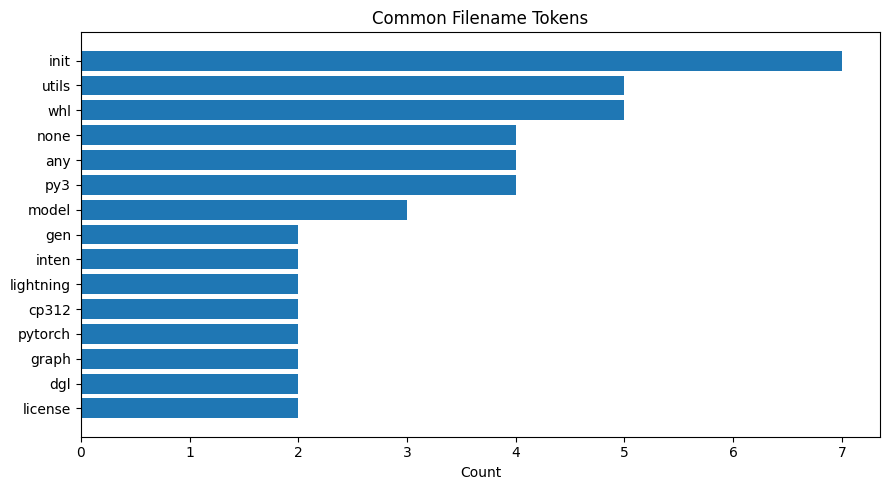

In [24]:
top=token_df.head(15).sort_values("count")
plt.figure(figsize=(9,5)); plt.barh(top.token,top["count"]); plt.xlabel("Count"); plt.title("Common Filename Tokens"); plt.tight_layout(); plt.show()

## 24.Compare metadata and software storage

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

,file_count
category,
Software/binary,37
Metadata/text,3


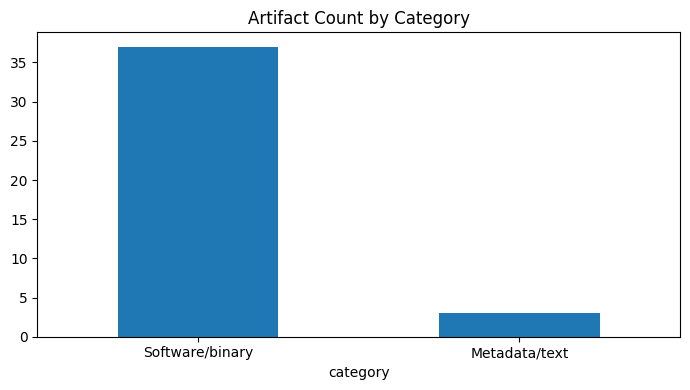

In [25]:
inventory["category"]=np.where(inventory.extension.isin([".json",".txt",".md",".toml"]),"Metadata/text","Software/binary")
g=inventory.groupby("category").size().sort_values(ascending=False)
display(g.to_frame("file_count"))
plt.figure(figsize=(7,4)); g.plot(kind="bar"); plt.title("Artifact Count by Category"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 25.Check duplicate artifacts

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [26]:
dupes=checksums[checksums.duplicated("sha256",keep=False)].sort_values("sha256")
print("No duplicate hashes found." if dupes.empty else "Duplicate artifacts:")
if not dupes.empty: display(dupes)

No duplicate hashes found.


## 26.Check empty or tiny artifacts

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [27]:
small=inventory[inventory.size_bytes<1024]
print("No files below 1 KiB." if small.empty else "Files below 1 KiB:")
if not small.empty: display(small)

Files below 1 KiB:


,file_name,relative_path,extension,size_bytes,size_mb,category
34,LICENSE-NOTICE.txt,LICENSE-NOTICE.txt,.txt,1003,0.000957,Metadata/text
35,pytorch.py,shim/dgl/backend/pytorch.py,.py,964,0.000919,Software/binary
36,__init__.py,src/ms_pred/common/__init__.py,.py,381,0.000363,Software/binary
37,__init__.py,src/ms_pred/nn_utils/__init__.py,.py,378,0.000360,Software/binary
38,__init__.py,src/ms_pred/__init__.py,.py,266,0.000254,Software/binary
39,__init__.py,shim/dgl/backend/__init__.py,.py,36,0.000034,Software/binary


## 27.Build compatibility report

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [28]:
compat=inventory[["file_name","relative_path","extension","size_mb"]].copy()
compat["python_abi"]=compat.file_name.str.extract(r"(cp3\d{1,2}|pp3\d{1,2}|py3(?:\.\d+)?)",expand=False)
compat["cuda"]=compat.file_name.str.extract(r"(cuda[._-]?\d+(?:[._]\d+)?)",expand=False,flags=re.I)
compat["iceberg_related"]=compat.file_name.str.contains(r"iceberg|ms[_-]?pred",case=False,regex=True)
compat["native_library"]=compat.extension.isin([".so",".dll",".dylib"])
display(compat)

,file_name,relative_path,extension,size_mb,python_abi,cuda,iceberg_related,native_library
0,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,wheels/rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.ice,34.445898,cp312,NaN,False,False
1,gen.pt,ckpt/gen.pt,.pt,13.886684,NaN,NaN,False,False
2,inten.pt,ckpt/inten.pt,.pt,13.154065,NaN,NaN,False,False
3,torchmetrics-1.9.0-py3-none-any.whl.ice,wheels/torchmetrics-1.9.0-py3-none-any.whl.ice,.ice,0.937828,py3,NaN,False,False
4,pytorch_lightning-2.6.6-py3-none-any.whl.ice,wheels/pytorch_lightning-2.6.6-py3-none-any.whl.ice,.ice,0.813527,py3,NaN,False,False
5,misc_utils.py,src/ms_pred/common/misc_utils.py,.py,0.092495,NaN,NaN,False,False
6,einops-0.8.2-py3-none-any.whl.ice,wheels/einops-0.8.2-py3-none-any.whl.ice,.ice,0.062597,py3,NaN,False,False
7,nn_utils.py,src/ms_pred/nn_utils/nn_utils.py,.py,0.039422,NaN,NaN,False,False
8,dag_data.py,src/ms_pred/iceberg/dag_data.py,.py,0.034480,NaN,NaN,False,False
9,gen_model.py,src/ms_pred/iceberg/gen_model.py,.py,0.033249,NaN,NaN,False,False


## 28.Inspect Python source files

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [29]:
py_files=[p for p in dataset_files if p.suffix.lower()==".py"]
rows=[]
for p in py_files:
    try:
        text=p.read_text(encoding="utf-8",errors="ignore")
        rows.append({"file":str(p.relative_to(DATA_DIR)),"lines":len(text.splitlines()),"imports":len(re.findall(r"^(?:from|import)\s+",text,re.M))})
    except Exception: pass
display(pd.DataFrame(rows) if rows else pd.DataFrame(columns=["file","lines","imports"]))

,file,lines,imports
0,ice_runner.py,760,2
1,fuse.py,160,1
2,shim/dgl/function.py,78,1
3,shim/dgl/__init__.py,277,6
4,shim/torch_scatter/__init__.py,80,1
5,shim/dgl/nn/__init__.py,55,2
6,shim/dgl/backend/pytorch.py,22,1
7,shim/dgl/backend/__init__.py,1,1
8,src/ms_pred/__init__.py,11,0
9,src/ms_pred/magma/fragmentation.py,767,6


## 29.Inspect native-library artifacts

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [30]:
native=[p for p in dataset_files if p.suffix.lower() in {".so",".dll",".dylib"}]
display(pd.DataFrame([{"file":str(p.relative_to(DATA_DIR)),"size_mb":p.stat().st_size/1024**2,"extension":p.suffix.lower()} for p in native]))

""


## 30.Optional offline installation candidates

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [31]:
print("Offline wheel candidates:")
for p in wheel_files: print(" -",p)
print("\nNo installation is performed automatically. Use --no-index if you test a wheel offline.")

Offline wheel candidates:

No installation is performed automatically. Use --no-index if you test a wheel offline.


## 31.Verify package metadata against filenames

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [32]:
rows=[]
if not metadata_df.empty:
    for _,r in metadata_df.iterrows():
        rows.append({"artifact":r["artifact"],"package":r.get("Name",""),"metadata_version":r.get("Version",""),"filename_versions":", ".join(version_pattern.findall(r["artifact"])) if "version_pattern" in globals() else ""})
display(pd.DataFrame(rows))

,artifact,package,metadata_version,filename_versions
0,einops-0.8.2-py3-none-any.whl.ice,einops,0.8.2,
1,torchmetrics-1.9.0-py3-none-any.whl.ice,torchmetrics,1.9.0,
2,lightning_utilities-0.15.3-py3-none-any.whl.ice,lightning-utilities,0.15.3,
3,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,rdkit,2025.3.6,
4,pytorch_lightning-2.6.6-py3-none-any.whl.ice,pytorch-lightning,2.6.6,


## 32.Create final artifact report

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [33]:
artifact_report=compat.merge(checksums[["file","sha256"]].rename(columns={"file":"file_name"}),on="file_name",how="left").sort_values("size_mb",ascending=False)
display(artifact_report)

,file_name,relative_path,extension,size_mb,python_abi,cuda,iceberg_related,native_library,sha256
0,rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,wheels/rdkit-2025.3.6-cp312-cp312-manylinux_2_28_x86_64.whl.ice,.ice,34.445898,cp312,NaN,False,False,ed5565d4d6423def7c52eb20a6263afcd979383757086dec92f57e77d7c7f856
1,gen.pt,ckpt/gen.pt,.pt,13.886684,NaN,NaN,False,False,deef0451c1870d2125653bb212c9d95c5b5d9bf80156dfa9b22fedda7db49bea
2,inten.pt,ckpt/inten.pt,.pt,13.154065,NaN,NaN,False,False,c49e330e049d3a8b0095026ed694fcf70045c24305354853732aaa5f89d55068
3,torchmetrics-1.9.0-py3-none-any.whl.ice,wheels/torchmetrics-1.9.0-py3-none-any.whl.ice,.ice,0.937828,py3,NaN,False,False,bfdcbff3dd1d96b3374bb2496eb39f23c4b28b8a845b6a18c313688e0d2d9ca1
4,pytorch_lightning-2.6.6-py3-none-any.whl.ice,wheels/pytorch_lightning-2.6.6-py3-none-any.whl.ice,.ice,0.813527,py3,NaN,False,False,71f95c7b22f25c4f91cc659e1734bcdc6c69c8b66543f2ed2d78dbe29ce2f167
...,...,...,...,...,...,...,...,...,...
77,__init__.py,shim/dgl/backend/__init__.py,.py,0.000034,NaN,NaN,False,False,cd78a6aaee83a58cadb14a9a41f8c8e92a07c3c2bba52f6a83b4eb8ac4fd62a2
78,__init__.py,shim/dgl/backend/__init__.py,.py,0.000034,NaN,NaN,False,False,f85e782b33669b9567ba24c46931db87506637870d723c8696e66515ff0f9ee7
79,__init__.py,shim/dgl/backend/__init__.py,.py,0.000034,NaN,NaN,False,False,e4a927730a084dd169e994b1fa712c5e17709e0a869f00aadb4709df9855c487
80,__init__.py,shim/dgl/backend/__init__.py,.py,0.000034,NaN,NaN,False,False,2f7f5b3d2537b6bde6a28be84908826901cb2306756b680a57934c39831ade57


## 33.Export final report

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [34]:
report_path=Path("/kaggle/working/casmi26_iceberg_artifact_report.csv")
artifact_report.to_csv(report_path,index=False)
print("Saved:",report_path)

Saved: /kaggle/working/casmi26_iceberg_artifact_report.csv


## 34.Final findings and reproducibility summary

This section analyzes the **casmi26-iceberg** software/artifact dataset and explains the purpose of the following code.

In [35]:
print("="*70)
print("CASMI26 ICEBERG FINAL SUMMARY")
print("="*70)
print("Artifacts:",len(dataset_files))
print(f"Storage: {total_bytes/1024**2:.2f} MB")
print("Wheels:",len(wheel_files))
print("ZIP-compatible:",len(zip_files))
print("Python files:",len(py_files))
print("Native files:",len(native))
print("\nCompleted: inventory, formats, versions, compatibility, ICEBERG search, checksums, wheel metadata, dependencies, RECORD analysis, package structure, and final CSV export.")
print("\nConclusion: casmi26-iceberg is a software/runtime artifact dataset used in the CASMI26 mass-spectrometry molecule-identification ecosystem; it should be analyzed as a reproducible package/runtime collection rather than as a conventional tabular ML dataset.")

CASMI26 ICEBERG FINAL SUMMARY
Artifacts: 40
Storage: 63.82 MB
Wheels: 0
ZIP-compatible: 7
Python files: 29
Native files: 0

Completed: inventory, formats, versions, compatibility, ICEBERG search, checksums, wheel metadata, dependencies, RECORD analysis, package structure, and final CSV export.

Conclusion: casmi26-iceberg is a software/runtime artifact dataset used in the CASMI26 mass-spectrometry molecule-identification ecosystem; it should be analyzed as a reproducible package/runtime collection rather than as a conventional tabular ML dataset.
